
## Lab 2: Seaborn (From Matplolib and pandas to seaborn)

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

## Laboratorio 2

1. Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al $95$ C.L. Usar `seaborn`. Give some conclusions.     

2. Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv
  desde GitHUb y reconstruir la figura 6 del [trabajo](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029). Para ello usar `seaborn` y `matplolib`.

  * $M_N=h_s\dfrac{v_s}{\sqrt{2}}$ 
  * $v_s =$ vS
  * $h_s=$ YRC
  * $M_\Psi=$ MDF  
  * $M_{\chi_1^0}=$ mChi1
  * $\Omega_{\chi_1^0}=$ Omega
  * $\Omega_{DM}=0.12$



  



### Punto 1

In [3]:
filename = 'data/millas_por_galon.csv'
cars_df = pd.read_csv(filename)

FileNotFoundError: [Errno 2] No such file or directory: 'data/millas_por_galon.csv'

In [5]:
EL ARCHIVO ES LOCAL... LEER DE INTERNET. NO ME DEJA CORRER

SyntaxError: invalid syntax (2746071330.py, line 1)

In [3]:
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


Acá me di cuenta que en el dataset hay un par de filas que no tienen información acerca de `horsepower`, están vacías, y esto estaba rompiendo el ajuste polinómico de NumPy.

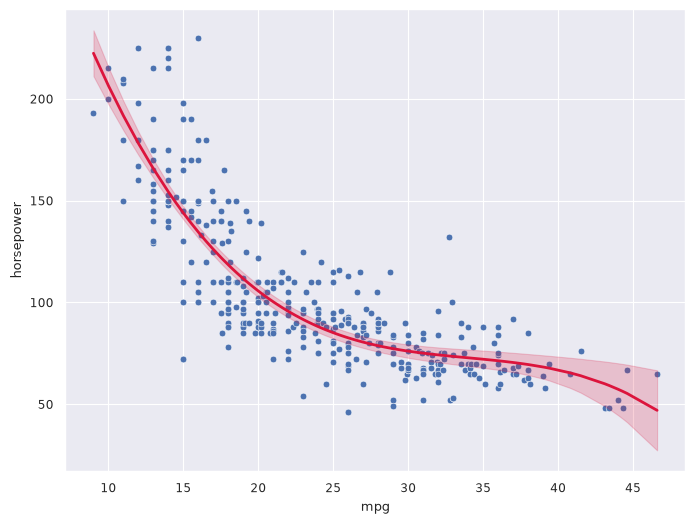

In [4]:
# Drop all rows with NaN values
cars_df = cars_df.drop(cars_df[cars_df["horsepower"].isna()].index)
# Sort by mpg in order to the polyfit to work
cars_df = cars_df.sort_values("mpg").reset_index(drop=True)

coef, cov = np.polyfit(cars_df["mpg"], cars_df["horsepower"], 3, cov=True)
poly = np.poly1d(coef)

x = cars_df["mpg"].unique()

V = np.vstack([x**deg for deg in range(3, -1, -1)]).T
y_sigma = np.sqrt(np.sum(np.dot(V, cov) * V, axis=1))

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(cars_df, x='mpg', y='horsepower', ax=ax)
plt.plot(x, poly(x), color="crimson", lw=2)
plt.fill_between(x, poly(x) - 2*y_sigma, poly(x) + 2*y_sigma, color="crimson", alpha=0.2)
plt.show()

No me parece que haya mucho que concluir sobre los datos en sí, sino sobre el ajuste. Un ajuste polinómico de grado 3 parece adaptarse correctamente a los datos, y es muy importante notar que el nivel de confianza es muy probable que no sea correcto tal y como lo calculé (utilizando la matriz de covarianza que devuelve numpy al hacer el ajuste), pues esto habla más de la varianza de los parámetros que de los datos en sí mismos. Es decir, según entiendo, la región sombreada indica con un 95% de nivel de confianza la zona en donde podría estar el ajuste polinómico.

no lo hace realmente con seaborn, sino que lo hace con matplotlib. Seaborn se utiliza para crear el scatterplot, pero la línea de ajuste polinomial y la banda de confianza se dibujan con NUMPY Y matplotlib.
colocar la funcion polinomica...??? PONERLA

### Punto 2

NO DEJA CORRER

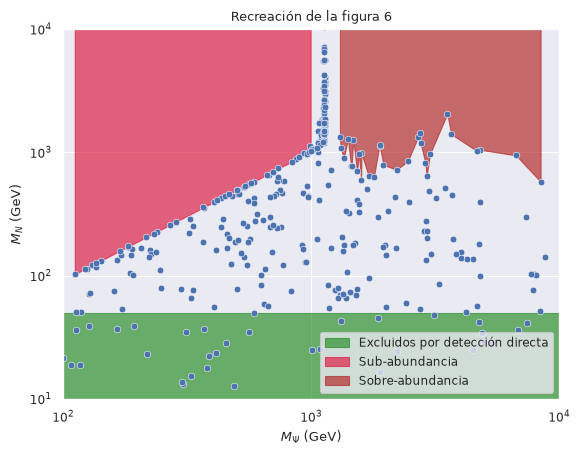

In [5]:
df = pd.read_csv("data/general-scan.csv")

df["mN"] = df["YRC"] * df["vS"] / np.sqrt(2)

correct_density = df[np.logical_and(df["Omega"] < (0.12 + 1e-3), df["Omega"] > (0.12 - 1e-3))]

# Esta solución me parece terrible para las regiones de sobre y sub abundancia, pero no encuentro otra manera de hacerlo
first_x = np.sort(correct_density[np.logical_and(correct_density["MDF"] <= 1e3, correct_density["mN"] >= (correct_density["MDF"] - 10))].MDF.array)
first_y = np.array([correct_density[correct_density["MDF"] == x].mN.max() for x in first_x])

second_x = np.sort(correct_density[np.logical_and(correct_density["MDF"] >= 1.21e3, correct_density["mN"] >= 5.2e2)].MDF.array)
second_y = np.array([correct_density[correct_density["MDF"] == x].mN.max() for x in second_x])

sns.scatterplot(correct_density, x="MDF", y="mN", zorder=2)
plt.axhspan(10, 50, color="forestgreen", alpha=0.65, label="Excluidos por detección directa", zorder=1)
plt.fill_between(first_x, first_y, 1e4, color="crimson", alpha=0.65, label="Sub-abundancia")
plt.fill_between(second_x, second_y, 1e4, color="firebrick", alpha=0.65, label="Sobre-abundancia")

plt.ylim(10, 1e4)
plt.xlim(1e2, 1e4)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$M_\Psi\;(\mathrm{GeV})$")
plt.ylabel(r"$M_N\;(\mathrm{GeV})$")
plt.title("Recreación de la figura 6")
plt.legend(loc="lower right")
plt.show()

No quedó tan linda ni quedó igual, pues no supe cómo hacer de manera programática que las regiones de sub y sobre-abundancia se vieran iguales que en el paper.

BIEN... NOTA 4.5